# 05 - Strategy Optimization

**Tujuan:** Cari kombinasi parameter terbaik untuk strategi trade signal.

**Parameter yang di-sweep:**
- RSI threshold (buy/sell bias)
- Indikator minimum (3/4 vs 4/4)
- ATR minimum filter
- TP multiplier (RR ratio)
- Jam trading (session filter)

## 1. Import & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 100

CSV_PATH = '../../app/ai/candle_ai/EURUSD.m_M15_202112160545_202603251830.csv'

df_raw = pd.read_csv(CSV_PATH, sep='\t')
df_raw.columns = df_raw.columns.str.strip('<>').str.lower()
df_raw['datetime'] = pd.to_datetime(df_raw['date'] + ' ' + df_raw['time'])
df_raw = df_raw.set_index('datetime').drop(columns=['date','time'])
df_raw = df_raw.rename(columns={'tickvol':'tick_vol'}).sort_index()

print(f'Data loaded: {df_raw.shape}')
print(f'Range: {df_raw.index.min()} -> {df_raw.index.max()}')

Data loaded: (100267, 7)
Range: 2021-12-16 05:45:00 -> 2026-03-25 18:30:00


## 2. Hitung Semua Indikator (sekali saja)

In [2]:
def ema(s, p):      return s.ewm(span=p, adjust=False).mean()
def atr_calc(df, p=14):
    tr = pd.concat([
        df['high'] - df['low'],
        (df['high'] - df['close'].shift()).abs(),
        (df['low']  - df['close'].shift()).abs()
    ], axis=1).max(axis=1)
    return tr.rolling(p).mean()

df = df_raw.copy()

# H1 resample
df_h1 = df.resample('1h').agg({'open':'first','high':'max','low':'min','close':'last'}).dropna()
df_h1['ema_50']  = ema(df_h1['close'], 50)
df_h1['ema_200'] = ema(df_h1['close'], 200)
df_h1['trend']   = np.where(df_h1['ema_50'] > df_h1['ema_200'], 'up',
                   np.where(df_h1['ema_50'] < df_h1['ema_200'], 'down', 'sideways'))

# M15 indicators
close = df['close']
# RSI
delta = close.diff()
df['rsi'] = 100 - (100 / (1 + delta.clip(lower=0).rolling(14).mean() /
                              (-delta.clip(upper=0)).rolling(14).mean().replace(0, 1e-10)))
# MACD
df['macd_line'] = ema(close,12) - ema(close,26)
df['macd_sig']  = ema(df['macd_line'], 9)
# EMA
df['ema_9']  = ema(close, 9)
df['ema_21'] = ema(close, 21)
# BB
df['bb_mid'] = close.rolling(20).mean()
# ATR
df['atr'] = atr_calc(df, 14)
# H1 trend merge
df['h1_trend'] = df_h1['trend'].reindex(df.index, method='ffill')
df['hour']     = df.index.hour

# Precompute arrays for speed
close_arr = df['close'].values
high_arr  = df['high'].values
low_arr   = df['low'].values
idx_arr   = df.index
m15_idx   = {dt: i for i, dt in enumerate(idx_arr)}

print('Indikator selesai.')
print(f'H1 trend distribution: {df["h1_trend"].value_counts().to_dict()}')

Indikator selesai.
H1 trend distribution: {'down': 50689, 'up': 49577, 'sideways': 1}


## 3. Backtest Engine (Vectorized)

In [3]:
def run_backtest(params):
    """
    params dict:
      rsi_buy    : RSI threshold untuk buy bias (default 40)
      rsi_sell   : RSI threshold untuk sell bias (default 60)
      min_ind    : minimal indikator setuju (3 atau 4)
      atr_min    : ATR minimum dalam pips
      tp_mult    : TP multiplier terhadap ATR
      sl_mult    : SL multiplier terhadap ATR
      hours      : list jam yang dibolehkan (None = semua jam)
      max_candle : max hold candle
    """
    rsi_buy    = params.get('rsi_buy',    40)
    rsi_sell   = params.get('rsi_sell',   60)
    min_ind    = params.get('min_ind',     3)
    atr_min    = params.get('atr_min', 0.0005)
    tp_mult    = params.get('tp_mult',   1.5)
    sl_mult    = params.get('sl_mult',   1.0)
    hours      = params.get('hours',    None)
    max_candle = params.get('max_candle', 20)
    spread     = 0.0001  # 1 pip spread

    # Hitung bias per baris
    rsi_bias  = np.where(df['rsi'] <= rsi_buy, 1,
                np.where(df['rsi'] >= rsi_sell, -1, 0))
    macd_bias = np.where(df['macd_line'] > df['macd_sig'], 1,
                np.where(df['macd_line'] < df['macd_sig'], -1, 0))
    ema_bias  = np.where(df['ema_9'] > df['ema_21'], 1,
                np.where(df['ema_9'] < df['ema_21'], -1, 0))
    bb_bias   = np.where(df['close'] < df['bb_mid'], 1,
                np.where(df['close'] > df['bb_mid'], -1, 0))

    buy_cnt  = ((rsi_bias==1).astype(int) + (macd_bias==1).astype(int) +
                (ema_bias==1).astype(int) + (bb_bias==1).astype(int))
    sell_cnt = ((rsi_bias==-1).astype(int) + (macd_bias==-1).astype(int) +
                (ema_bias==-1).astype(int) + (bb_bias==-1).astype(int))

    atr_arr_pip = df['atr'].values / 0.0001
    trend_arr   = df['h1_trend'].values
    hour_arr    = df['hour'].values

    wins = losses = timeouts = 0
    pnl_total = 0.0
    trade_count = 0

    for i in range(200, len(df) - max_candle):
        atr_pip = atr_arr_pip[i]
        if np.isnan(atr_pip) or atr_pip < atr_min:
            continue
        if hours is not None and hour_arr[i] not in hours:
            continue

        trend = trend_arr[i]
        bc    = buy_cnt[i]
        sc    = sell_cnt[i]

        if trend == 'up'   and bc >= min_ind:
            signal = 'buy'
        elif trend == 'down' and sc >= min_ind:
            signal = 'sell'
        else:
            continue

        entry = close_arr[i]
        atr_v = df['atr'].values[i]
        sl    = entry - sl_mult * atr_v if signal=='buy' else entry + sl_mult * atr_v
        tp    = entry + tp_mult * atr_v if signal=='buy' else entry - tp_mult * atr_v

        outcome    = 'timeout'
        exit_price = close_arr[i + max_candle]

        for j in range(1, max_candle + 1):
            h = high_arr[i + j]
            l = low_arr[i + j]
            if signal == 'buy':
                if l <= sl: outcome = 'loss'; exit_price = sl;  break
                if h >= tp: outcome = 'win';  exit_price = tp;  break
            else:
                if h >= sl: outcome = 'loss'; exit_price = sl;  break
                if l <= tp: outcome = 'win';  exit_price = tp;  break

        pnl = (exit_price - entry) / 0.0001 if signal=='buy' else (entry - exit_price) / 0.0001
        pnl -= 1  # spread 1 pip

        pnl_total += pnl
        trade_count += 1
        if outcome == 'win':     wins    += 1
        elif outcome == 'loss':  losses  += 1
        else:                    timeouts += 1

    if trade_count == 0:
        return {'trades':0,'wr':0,'pips':0,'pf':0}

    wr = wins / trade_count * 100
    pf = (wins * tp_mult) / (losses + timeouts * 0.5 + 1e-10)
    return {'trades': trade_count, 'wr': round(wr,1), 'pips': round(pnl_total,0), 'pf': round(pf,2)}

# Test baseline
baseline = run_backtest({})
print('Baseline:', baseline)

Baseline: {'trades': 5855, 'wr': 37.4, 'pips': np.float64(-5574.0), 'pf': 0.94}


## 4. Parameter Sweep

In [4]:
param_grid = {
    'rsi_buy':  [40, 35, 30],
    'rsi_sell': [60, 65, 70],
    'min_ind':  [3, 4],
    'atr_min':  [5, 8, 10, 15],
    'tp_mult':  [1.5, 2.0, 2.5, 3.0],
    'hours':    [
        None,                          # semua jam
        list(range(7, 17)),            # London+NY session (07-17 UTC)
        list(range(7, 12)),            # London open (07-12 UTC)
        list(range(13, 17)),           # NY open (13-17 UTC)
        [5, 6, 7, 8, 9, 10, 11],      # pre+London
    ]
}

# Generate semua kombinasi
keys   = list(param_grid.keys())
combos = list(product(*param_grid.values()))
print(f'Total kombinasi: {len(combos):,}')
print('Running...')

results = []
for i, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    # Pastikan rsi_buy < rsi_sell
    if params['rsi_buy'] >= params['rsi_sell']:
        continue
    res = run_backtest(params)
    if res['trades'] >= 50:  # minimal 50 trade agar valid
        results.append({**params, **res})

df_res = pd.DataFrame(results)
df_res['session'] = df_res['hours'].apply(
    lambda x: 'all' if x is None
    else 'london_ny' if x == list(range(7,17))
    else 'london'    if x == list(range(7,12))
    else 'ny'        if x == list(range(13,17))
    else 'pre_london'
)

print(f'\nKombinasi valid (>= 50 trades): {len(df_res):,}')
print(f'Range win rate: {df_res["wr"].min():.1f}% - {df_res["wr"].max():.1f}%')
print(f'Range pips: {df_res["pips"].min():.0f} - {df_res["pips"].max():.0f}')

Total kombinasi: 1,440
Running...



Kombinasi valid (>= 50 trades): 540
Range win rate: 9.9% - 45.4%
Range pips: -3447 - 1326


## 5. Top 20 Kombinasi Terbaik

In [5]:
# Score = gabungan win rate + total pips (normalized)
df_res['wr_norm']   = (df_res['wr']   - df_res['wr'].min())   / (df_res['wr'].max()   - df_res['wr'].min() + 1e-10)
df_res['pips_norm'] = (df_res['pips'] - df_res['pips'].min()) / (df_res['pips'].max() - df_res['pips'].min() + 1e-10)
df_res['score']     = 0.5 * df_res['wr_norm'] + 0.5 * df_res['pips_norm']

top20 = df_res.sort_values('score', ascending=False).head(20)

print('=== TOP 20 KOMBINASI PARAMETER ===')
cols = ['rsi_buy','rsi_sell','min_ind','atr_min','tp_mult','session','trades','wr','pips','pf']
print(top20[cols].to_string(index=False))

=== TOP 20 KOMBINASI PARAMETER ===
 rsi_buy  rsi_sell  min_ind  atr_min  tp_mult    session  trades   wr   pips   pf
      40        70        3       15      1.5        all     183 44.8  876.0 1.37
      40        65        3       15      1.5        all     212 43.4  823.0 1.28
      40        60        3       15      1.5        all     261 41.0  740.0 1.18
      30        60        3        5      1.5 pre_london     438 45.4  -43.0 1.25
      40        60        3        8      1.5 pre_london     217 44.7   45.0 1.23
      40        60        3        5      1.5 pre_london     663 45.1  -81.0 1.24
      40        60        3        8      1.5     london     159 44.0   36.0 1.20
      35        60        3        5      1.5 pre_london     495 44.8  -98.0 1.22
      30        60        3        5      1.5     london     322 44.4  -64.0 1.20
      40        60        3       15      1.5  london_ny      56 42.9  102.0 1.16
      35        70        3       15      1.5        all     11

## 6. Parameter Terbaik — Detail Backtest

In [6]:
best = df_res.sort_values('score', ascending=False).iloc[0]
print('=== PARAMETER TERBAIK ===')
print(f'RSI Buy/Sell  : <= {best["rsi_buy"]} / >= {best["rsi_sell"]}')
print(f'Min Indikator : {best["min_ind"]}/4')
print(f'ATR Minimum   : {best["atr_min"]} pips')
print(f'TP Multiplier : {best["tp_mult"]}x ATR')
print(f'Session       : {best["session"]}')
print(f'\nHasil:')
print(f'  Trades  : {best["trades"]:,}')
print(f'  Win Rate: {best["wr"]}%')
print(f'  Total Pips: {best["pips"]:+.0f}')
print(f'  Profit Factor: {best["pf"]}')

# Jalankan backtest detail dengan parameter terbaik
best_params = {
    'rsi_buy':  int(best['rsi_buy']),
    'rsi_sell': int(best['rsi_sell']),
    'min_ind':  int(best['min_ind']),
    'atr_min':  float(best['atr_min']),
    'tp_mult':  float(best['tp_mult']),
    'hours':    best['hours'],
    'max_candle': 20
}

=== PARAMETER TERBAIK ===
RSI Buy/Sell  : <= 40 / >= 70
Min Indikator : 3/4
ATR Minimum   : 15 pips
TP Multiplier : 1.5x ATR
Session       : all

Hasil:
  Trades  : 183
  Win Rate: 44.8%
  Total Pips: +876
  Profit Factor: 1.37


## 7. Visualisasi Hasil Sweep

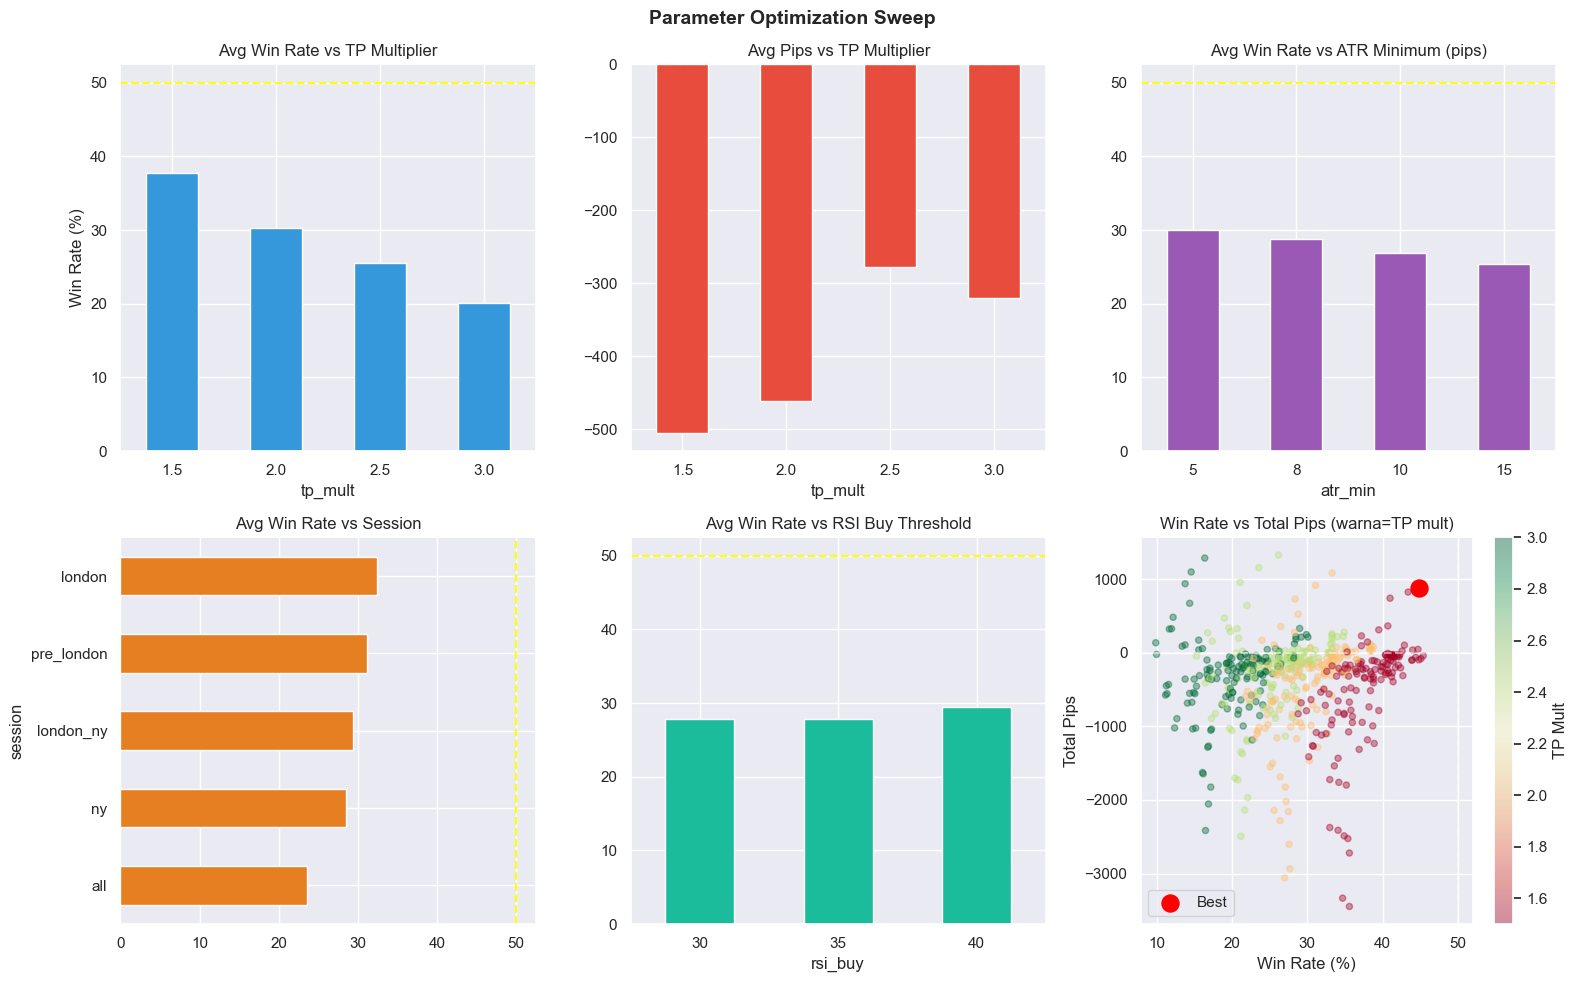

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Win rate vs TP multiplier
df_res.groupby('tp_mult')['wr'].mean().plot(kind='bar', ax=axes[0,0],
    color='#3498db', edgecolor='white')
axes[0,0].axhline(50, color='yellow', linestyle='--')
axes[0,0].set_title('Avg Win Rate vs TP Multiplier')
axes[0,0].set_ylabel('Win Rate (%)')
axes[0,0].tick_params(axis='x', rotation=0)

# Total pips vs TP multiplier
df_res.groupby('tp_mult')['pips'].mean().plot(kind='bar', ax=axes[0,1],
    color=['#2ecc71' if v >= 0 else '#e74c3c'
           for v in df_res.groupby('tp_mult')['pips'].mean()],
    edgecolor='white')
axes[0,1].axhline(0, color='white', linestyle='--')
axes[0,1].set_title('Avg Pips vs TP Multiplier')
axes[0,1].tick_params(axis='x', rotation=0)

# Win rate vs ATR minimum
df_res.groupby('atr_min')['wr'].mean().plot(kind='bar', ax=axes[0,2],
    color='#9b59b6', edgecolor='white')
axes[0,2].axhline(50, color='yellow', linestyle='--')
axes[0,2].set_title('Avg Win Rate vs ATR Minimum (pips)')
axes[0,2].tick_params(axis='x', rotation=0)

# Win rate vs Session
df_res.groupby('session')['wr'].mean().sort_values().plot(kind='barh', ax=axes[1,0],
    color='#e67e22', edgecolor='white')
axes[1,0].axvline(50, color='yellow', linestyle='--')
axes[1,0].set_title('Avg Win Rate vs Session')

# Win rate vs RSI buy threshold
df_res.groupby('rsi_buy')['wr'].mean().plot(kind='bar', ax=axes[1,1],
    color='#1abc9c', edgecolor='white')
axes[1,1].axhline(50, color='yellow', linestyle='--')
axes[1,1].set_title('Avg Win Rate vs RSI Buy Threshold')
axes[1,1].tick_params(axis='x', rotation=0)

# Scatter: win rate vs total pips
sc = axes[1,2].scatter(df_res['wr'], df_res['pips'],
    c=df_res['tp_mult'], cmap='RdYlGn', alpha=0.4, s=20)
axes[1,2].axhline(0,  color='white', linestyle='--', alpha=0.5)
axes[1,2].axvline(50, color='white', linestyle='--', alpha=0.5)
axes[1,2].set_title('Win Rate vs Total Pips (warna=TP mult)')
axes[1,2].set_xlabel('Win Rate (%)')
axes[1,2].set_ylabel('Total Pips')
plt.colorbar(sc, ax=axes[1,2], label='TP Mult')

# Mark best
axes[1,2].scatter(best['wr'], best['pips'], color='red', s=150, zorder=5, label='Best')
axes[1,2].legend()

plt.suptitle('Parameter Optimization Sweep', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('optimization_result.png', dpi=100, bbox_inches='tight')
plt.show()

## 8. Backtest Detail dengan Parameter Terbaik

=== HASIL BEST PARAMETER ===
Total Trade  : 183
Win Rate     : 44.8%
Total Pips   : +876
Max Drawdown : -147 pips


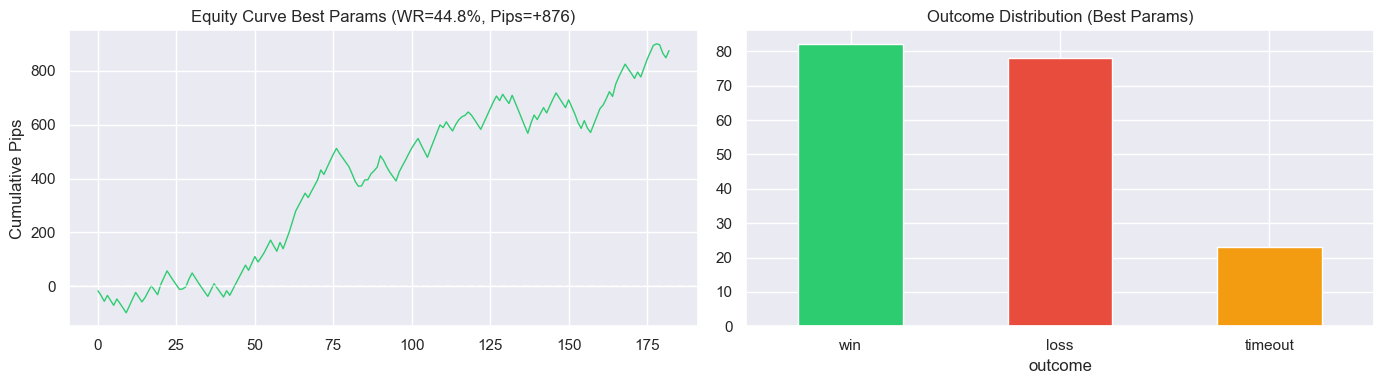

In [8]:
# Re-run backtest dengan simpan detail setiap trade
rsi_buy    = best_params['rsi_buy']
rsi_sell   = best_params['rsi_sell']
min_ind    = best_params['min_ind']
atr_min    = best_params['atr_min']
tp_mult    = best_params['tp_mult']
hours      = best_params['hours']
max_candle = best_params['max_candle']

rsi_bias  = np.where(df['rsi'] <= rsi_buy, 1, np.where(df['rsi'] >= rsi_sell, -1, 0))
macd_bias = np.where(df['macd_line'] > df['macd_sig'], 1, np.where(df['macd_line'] < df['macd_sig'], -1, 0))
ema_bias  = np.where(df['ema_9'] > df['ema_21'], 1, np.where(df['ema_9'] < df['ema_21'], -1, 0))
bb_bias   = np.where(df['close'] < df['bb_mid'], 1, np.where(df['close'] > df['bb_mid'], -1, 0))

buy_cnt  = (rsi_bias==1).astype(int) + (macd_bias==1).astype(int) + (ema_bias==1).astype(int) + (bb_bias==1).astype(int)
sell_cnt = (rsi_bias==-1).astype(int) + (macd_bias==-1).astype(int) + (ema_bias==-1).astype(int) + (bb_bias==-1).astype(int)

atr_vals  = df['atr'].values
trend_arr = df['h1_trend'].values
hour_arr  = df['hour'].values

detail_results = []

for i in range(200, len(df) - max_candle):
    atr_pip = atr_vals[i] / 0.0001 if not np.isnan(atr_vals[i]) else 0
    if atr_pip < atr_min: continue
    if hours is not None and hour_arr[i] not in hours: continue

    trend = trend_arr[i]
    bc, sc = buy_cnt[i], sell_cnt[i]

    if trend == 'up'   and bc >= min_ind: signal = 'buy'
    elif trend == 'down' and sc >= min_ind: signal = 'sell'
    else: continue

    entry = close_arr[i]
    atr_v = atr_vals[i]
    sl    = entry - atr_v if signal=='buy' else entry + atr_v
    tp    = entry + tp_mult * atr_v if signal=='buy' else entry - tp_mult * atr_v

    outcome = 'timeout'; exit_price = close_arr[i + max_candle]; hold = max_candle
    for j in range(1, max_candle + 1):
        h, l = high_arr[i+j], low_arr[i+j]
        if signal=='buy':
            if l<=sl: outcome='loss'; exit_price=sl; hold=j; break
            if h>=tp: outcome='win';  exit_price=tp; hold=j; break
        else:
            if h>=sl: outcome='loss'; exit_price=sl; hold=j; break
            if l<=tp: outcome='win';  exit_price=tp; hold=j; break

    pnl = ((exit_price-entry) if signal=='buy' else (entry-exit_price)) / 0.0001 - 1

    detail_results.append({
        'datetime': idx_arr[i], 'signal': signal,
        'entry': entry, 'sl': sl, 'tp': tp,
        'exit_price': exit_price, 'outcome': outcome,
        'pnl_pips': round(pnl,1), 'hold_candles': hold,
        'atr_pips': round(atr_pip,1), 'h1_trend': trend, 'hour': hour_arr[i]
    })

bt_best = pd.DataFrame(detail_results)
bt_best['cum_pips'] = bt_best['pnl_pips'].cumsum()

wins_b   = (bt_best['outcome']=='win').sum()
total_b  = len(bt_best)
wr_b     = wins_b / total_b * 100
pips_b   = bt_best['pnl_pips'].sum()
max_dd_b = (bt_best['cum_pips'] - bt_best['cum_pips'].cummax()).min()

print('=== HASIL BEST PARAMETER ===')
print(f'Total Trade  : {total_b:,}')
print(f'Win Rate     : {wr_b:.1f}%')
print(f'Total Pips   : {pips_b:+.0f}')
print(f'Max Drawdown : {max_dd_b:.0f} pips')

# Equity curve
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
bt_best['cum_pips'].plot(ax=axes[0], color='#2ecc71', linewidth=1)
axes[0].axhline(0, color='white', linestyle='--', alpha=0.5)
axes[0].set_title(f'Equity Curve Best Params (WR={wr_b:.1f}%, Pips={pips_b:+.0f})')
axes[0].set_ylabel('Cumulative Pips')

bt_best['outcome'].value_counts().plot(kind='bar', ax=axes[1],
    color=['#2ecc71','#e74c3c','#f39c12'], edgecolor='white')
axes[1].set_title('Outcome Distribution (Best Params)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('best_params_equity.png', dpi=100, bbox_inches='tight')
plt.show()

## 9. Simpan Hasil & Rekomendasi

In [9]:
# Simpan top results
df_res.sort_values('score', ascending=False).head(50).to_csv(
    'optimization_top50.csv', index=False)

bt_best.to_csv('best_params_trades.csv', index=False)

print('=' * 52)
print('     REKOMENDASI PARAMETER OPTIMAL')
print('=' * 52)
print(f'RSI Buy     : <= {rsi_buy}')
print(f'RSI Sell    : >= {rsi_sell}')
print(f'Min Ind     : {min_ind}/4')
print(f'ATR Min     : {atr_min} pips')
print(f'TP Mult     : {tp_mult}x ATR')
print(f'SL Mult     : 1.0x ATR')
session_label = 'Semua jam' if hours is None else f'Jam {min(hours)}-{max(hours)} UTC'
print(f'Session     : {session_label}')
print(f'\nBaseline vs Best:')
print(f'  Win Rate  : 35.6% -> {wr_b:.1f}%')
print(f'  Total Pips: -3448 -> {pips_b:+.0f}')
print(f'  Max DD    : -3697 -> {max_dd_b:.0f}')
print('=' * 52)
print('\nFile tersimpan:')
print('  optimization_top50.csv')
print('  best_params_trades.csv')
print('  optimization_result.png')
print('  best_params_equity.png')

     REKOMENDASI PARAMETER OPTIMAL
RSI Buy     : <= 40
RSI Sell    : >= 70
Min Ind     : 3/4
ATR Min     : 15.0 pips
TP Mult     : 1.5x ATR
SL Mult     : 1.0x ATR
Session     : Semua jam

Baseline vs Best:
  Win Rate  : 35.6% -> 44.8%
  Total Pips: -3448 -> +876
  Max DD    : -3697 -> -147

File tersimpan:
  optimization_top50.csv
  best_params_trades.csv
  optimization_result.png
  best_params_equity.png
